<a href="https://colab.research.google.com/github/nguyenthaibaok5bt-png/THDeepLearning/blob/main/THDeepLearningB2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    area  price
0     40   1.00
1     45   1.10
2     50   1.20
3     55   1.35
4     60   1.50
5     65   1.65
6     70   1.80
7     75   1.90
8     80   2.00
9     85   2.15
10    90   2.30
11    95   2.40
12   100   2.50
13   105   2.65
14   110   2.80
15   115   2.90
16   120   3.00
17   125   3.10
18   130   3.20
19   135   3.30
20   140   3.40
21   145   3.45
22   150   3.50
23   155   3.60
24   160   3.70
25   165   3.75
26   170   3.80
27   175   3.90
28   180   4.00
29   185   4.05
30   190   4.10
31   195   4.15
32   200   4.20
33   210   4.40
34   220   4.60
35   230   4.80
36   240   5.00
37   250   5.20
38   260   5.40
39   270   5.50
40   280   5.70
41   300   6.00
Epoch 0, Train Loss = 1.5365371704101562, Test Loss = 1.3842272758483887
Epoch 100, Train Loss = 0.03944822773337364, Test Loss = 0.03392560034990311
Epoch 200, Train Loss = 0.013117519207298756, Test Loss = 0.008317979983985424
Epoch 300, Train Loss = 0.012654408812522888, Test Loss = 0.0076211076229810715
Epo

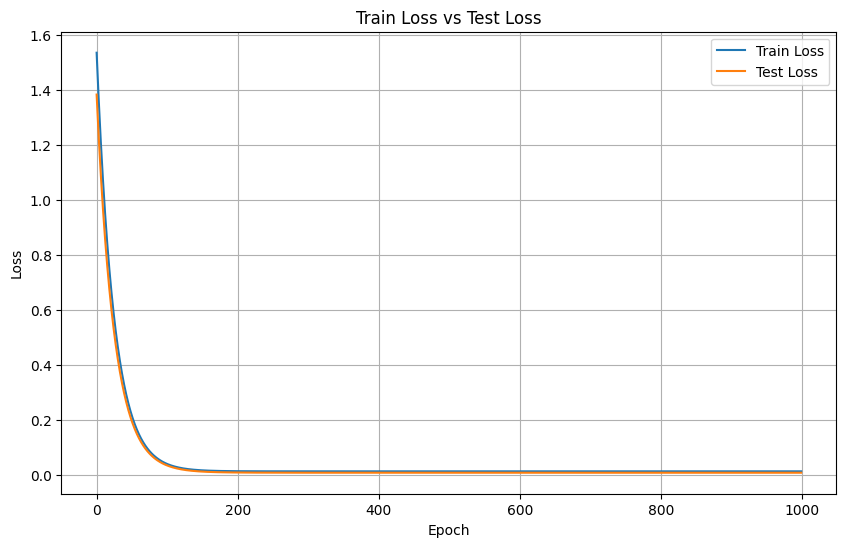

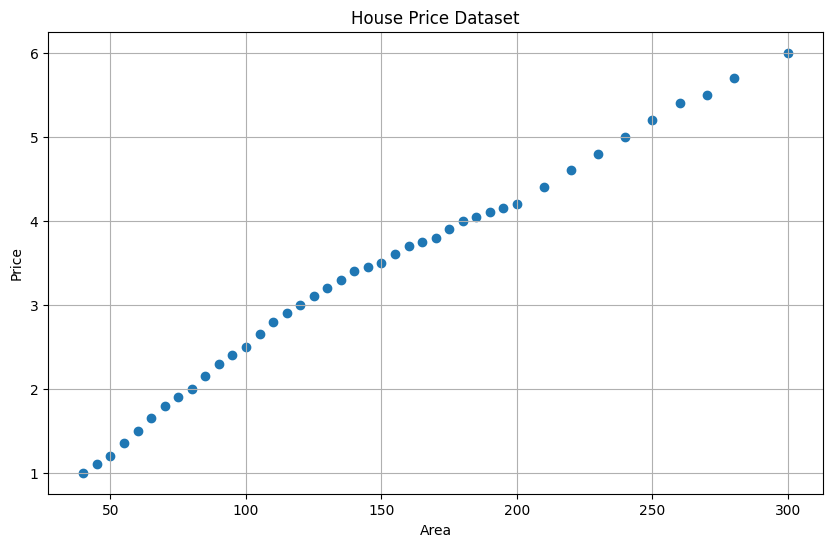

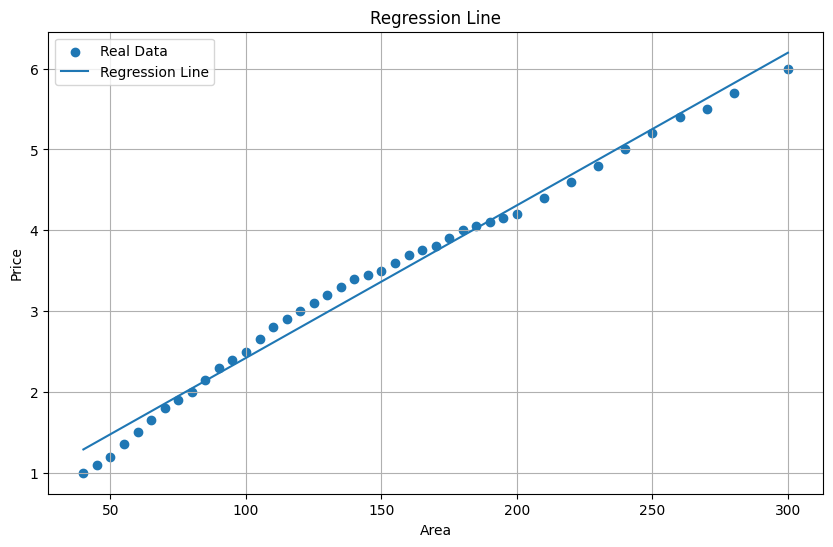

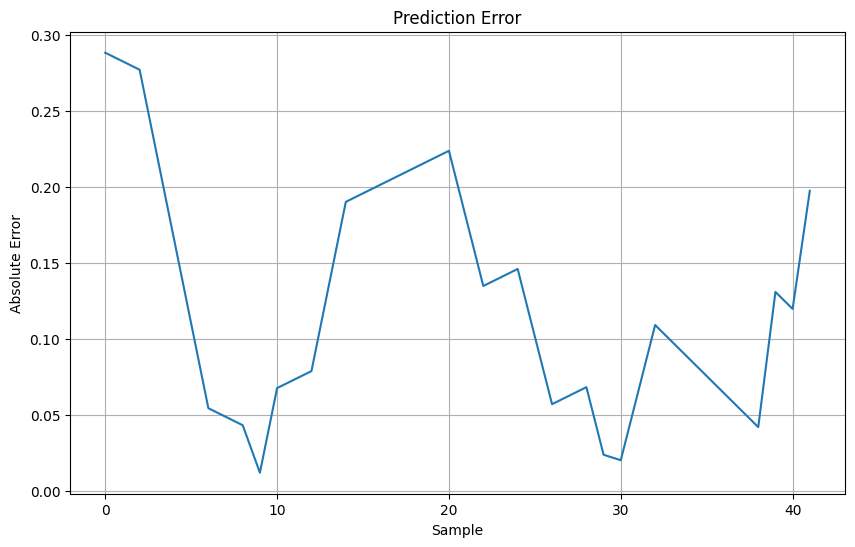


Model Weight:
Parameter containing:
tensor([[0.9937]], requires_grad=True)

Model Bias:
Parameter containing:
tensor([-2.4860e-08], requires_grad=True)


In [1]:
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


data = {

    'area': [
        40, 45, 50, 55, 60,
        65, 70, 75, 80, 85,
        90, 95, 100, 105, 110,
        115, 120, 125, 130, 135,
        140, 145, 150, 155, 160,
        165, 170, 175, 180, 185,
        190, 195, 200, 210, 220,
        230, 240, 250, 260, 270,
        280, 300
    ],

    'price': [
        1.0, 1.1, 1.2, 1.35, 1.5,
        1.65, 1.8, 1.9, 2.0, 2.15,
        2.3, 2.4, 2.5, 2.65, 2.8,
        2.9, 3.0, 3.1, 3.2, 3.3,
        3.4, 3.45, 3.5, 3.6, 3.7,
        3.75, 3.8, 3.9, 4.0, 4.05,
        4.1, 4.15, 4.2, 4.4, 4.6,
        4.8, 5.0, 5.2, 5.4, 5.5,
        5.7, 6.0
    ]
}

df = pd.DataFrame(data)

print(df)


X = df[['area']].values
y = df[['price']].values


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# SCALER

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# TENSOR

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_scaled,
    dtype=torch.float32
)

# MODEL

model = nn.Linear(1, 1)

# LOSS FUNCTION

loss_fn = nn.MSELoss()

# OPTIMIZER

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

# TRAIN

epochs = 1000

train_losses = []
test_losses = []

for epoch in range(epochs):

    # TRAIN

    y_pred = model(X_train_tensor)

    train_loss = loss_fn(
        y_pred,
        y_train_tensor
    )

    optimizer.zero_grad()

    train_loss.backward()

    optimizer.step()

    # TEST

    with torch.no_grad():

        test_pred = model(X_test_tensor)

        test_loss = loss_fn(
            test_pred,
            y_test_tensor
        )


    train_losses.append(
        train_loss.item()
    )

    test_losses.append(
        test_loss.item()
    )



    if epoch % 100 == 0:

        print(
            f"Epoch {epoch}, "
            f"Train Loss = {train_loss.item()}, "
            f"Test Loss = {test_loss.item()}"
        )

# PREDICT NHA MOI

new_house = [[150]]

# scale input
new_house_scaled = scaler_X.transform(
    new_house
)

# tensor
new_tensor = torch.tensor(
    new_house_scaled,
    dtype=torch.float32
)

# predict
pred_scaled = model(new_tensor)

# inverse scale
pred_price = scaler_y.inverse_transform(
    pred_scaled.detach().numpy()
)

print(
    "\nPredicted price 150m2:",
    pred_price
)

# VE BIEU DO LOSS

plt.figure(figsize=(10,6))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    test_losses,
    label="Test Loss"
)

plt.title("Train Loss vs Test Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.savefig("loss_curve.png")

plt.show()

# VE SCATTER DATASET

plt.figure(figsize=(10,6))

plt.scatter(
    X,
    y
)

plt.title("House Price Dataset")

plt.xlabel("Area")

plt.ylabel("Price")

plt.grid(True)

plt.show()

# VE DUONG REGRESSION

with torch.no_grad():

    all_scaled = scaler_X.transform(X)

    all_tensor = torch.tensor(
        all_scaled,
        dtype=torch.float32
    )

    pred_all_scaled = model(all_tensor)

    pred_all = scaler_y.inverse_transform(
        pred_all_scaled.numpy()
    )

plt.figure(figsize=(10,6))


plt.scatter(
    X,
    y,
    label="Real Data"
)

# đường predict
plt.plot(
    X,
    pred_all,
    label="Regression Line"
)

plt.title("Regression Line")

plt.xlabel("Area")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

# VE BIEU DO SAI SO

real_price = y.flatten()

predict_price = pred_all.flatten()

errors = abs(
    real_price - predict_price
)

plt.figure(figsize=(10,6))

plt.plot(errors)

plt.title("Prediction Error")

plt.xlabel("Sample")

plt.ylabel("Absolute Error")

plt.grid(True)

plt.show()

#  WEIGHT VA BIAS

print("\nModel Weight:")
print(model.weight)

print("\nModel Bias:")
print(model.bias)